# Student Academic Risk Prediction
## Notebook 04: Feature Engineering

In this notebook I create new features from the existing raw variables 
using domain reasoning, aggregations, and interaction terms.

Feature engineering is where domain knowledge meets mathematics. 
A well-engineered feature can improve model performance more than 
any amount of hyperparameter tuning.

My colour convention remains consistent throughout:
- 🔴 Red (#e74c3c) = At-Risk
- 🟢 Green (#2ecc71) = Passing

##  Imports & Load

In [1]:
# loading libraries and the combined raw dataset
# I engineer features on the raw data before final encoding
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', font_scale=1.2)

PALETTE = {'Passing': '#2ecc71', 'At-Risk': '#e74c3c'}

df = pd.read_csv('../data/processed/student_combined.csv')
df['Risk Status'] = df['at_risk'].map({0: 'Passing', 1: 'At-Risk'})

print(f"Dataset loaded: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset loaded: (1044, 36)
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'at_risk', 'subject', 'Risk Status']


## Feature Engineering Strategy

Before writing any code I document exactly what I plan to create and why.


| New Feature | Source Columns | Reasoning |
|---|---|---|
| `avg_alcohol` | Dalc, Walc | Average of weekday and weekend alcohol — captures overall consumption pattern |
| `parent_edu_avg` | Medu, Fedu | Average parental education — single socioeconomic signal |
| `parent_edu_max` | Medu, Fedu | Maximum parental education — captures the more educated parent's influence |
| `total_support` | famsup, schoolsup, paid | Combined support score — does the student have a safety net? |
| `social_score` | famrel, freetime, goout | Combined social engagement score |
| `health_risk_score` | health, avg_alcohol, absences | Composite lifestyle risk indicator |
| `is_first_gen` | Medu, Fedu | Binary — are both parents below secondary education? |
| `failure_absence_interaction` | failures, absences | Interaction term — high on both is a compounding risk signal |
| `study_support_ratio` | studytime, total_support | Study effort relative to support available |

I will validate each feature visually before including it in the final dataset.

## Engineer Features

In [2]:
df_feat = df.copy()

# --- 1. average alcohol consumption ---
# combining weekday and weekend drinking into a single lifestyle indicator
df_feat['avg_alcohol'] = (df_feat['Dalc'] + df_feat['Walc']) / 2

# --- 2. parental education features ---
# capturing both the average and the maximum educated parent
df_feat['parent_edu_avg'] = (df_feat['Medu'] + df_feat['Fedu']) / 2
df_feat['parent_edu_max'] = df_feat[['Medu', 'Fedu']].max(axis=1)

# --- 3. total support score ---
# counting how many support systems a student has access to
# schoolsup and famsup and paid are yes/no — converting to 1/0
support_cols = ['famsup', 'schoolsup', 'paid']
for col in support_cols:
    df_feat[col + '_bin'] = (df_feat[col] == 'yes').astype(int)

df_feat['total_support'] = (df_feat['famsup_bin'] +
                             df_feat['schoolsup_bin'] +
                             df_feat['paid_bin'])

# --- 4. social score ---
# combining family relationship quality, free time, and social outings
df_feat['social_score'] = (df_feat['famrel'] +
                            df_feat['freetime'] +
                            df_feat['goout'])

# --- 5. health risk score ---
# students with poor health, high alcohol, and many absences face compounding risk
df_feat['health_risk_score'] = (df_feat['avg_alcohol'] +
                                 (6 - df_feat['health']) +  # inverting health: low health = high risk
                                 np.log1p(df_feat['absences']))  # log to reduce skew of absences

# --- 6. first generation student flag ---
# binary: 1 if both parents have below secondary education (< 3)
df_feat['is_first_gen'] = ((df_feat['Medu'] < 3) &
                            (df_feat['Fedu'] < 3)).astype(int)

# --- 7. failure absence interaction ---
# a student failing AND missing school is a compounding risk signal
df_feat['failure_absence_interaction'] = (df_feat['failures'] *
                                           np.log1p(df_feat['absences']))

# --- 8. study support ratio ---
# how much is the student studying relative to their available support?
df_feat['study_support_ratio'] = df_feat['studytime'] / (df_feat['total_support'] + 1)

print("Features engineered successfully.")
new_features = ['avg_alcohol', 'parent_edu_avg', 'parent_edu_max',
                'total_support', 'social_score', 'health_risk_score',
                'is_first_gen', 'failure_absence_interaction',
                'study_support_ratio']
print(f"\nNew features created: {new_features}")
print(f"\nNew dataset shape: {df_feat.shape}")

Features engineered successfully.

New features created: ['avg_alcohol', 'parent_edu_avg', 'parent_edu_max', 'total_support', 'social_score', 'health_risk_score', 'is_first_gen', 'failure_absence_interaction', 'study_support_ratio']

New dataset shape: (1044, 48)


#### Engineering Note: Design Decisions

A few deliberate choices worth documenting:

**Log transformation on absences:** The absences column is heavily 
right-skewed — a small number of students have extremely high absence 
counts. Using `np.log1p()` compresses this range so extreme outliers 
don't dominate the composite scores.

**Inverting health score:** The health column runs 1 (very bad) to 
5 (very good). To make it consistent with risk direction — where a 
higher value means higher risk — I use `(6 - health)`. Now a value 
of 5 means very poor health, consistent with the other risk indicators.

**Adding 1 to denominator in study_support_ratio:** Prevents division 
by zero for students with no support systems at all.

## Validate New Features Visually

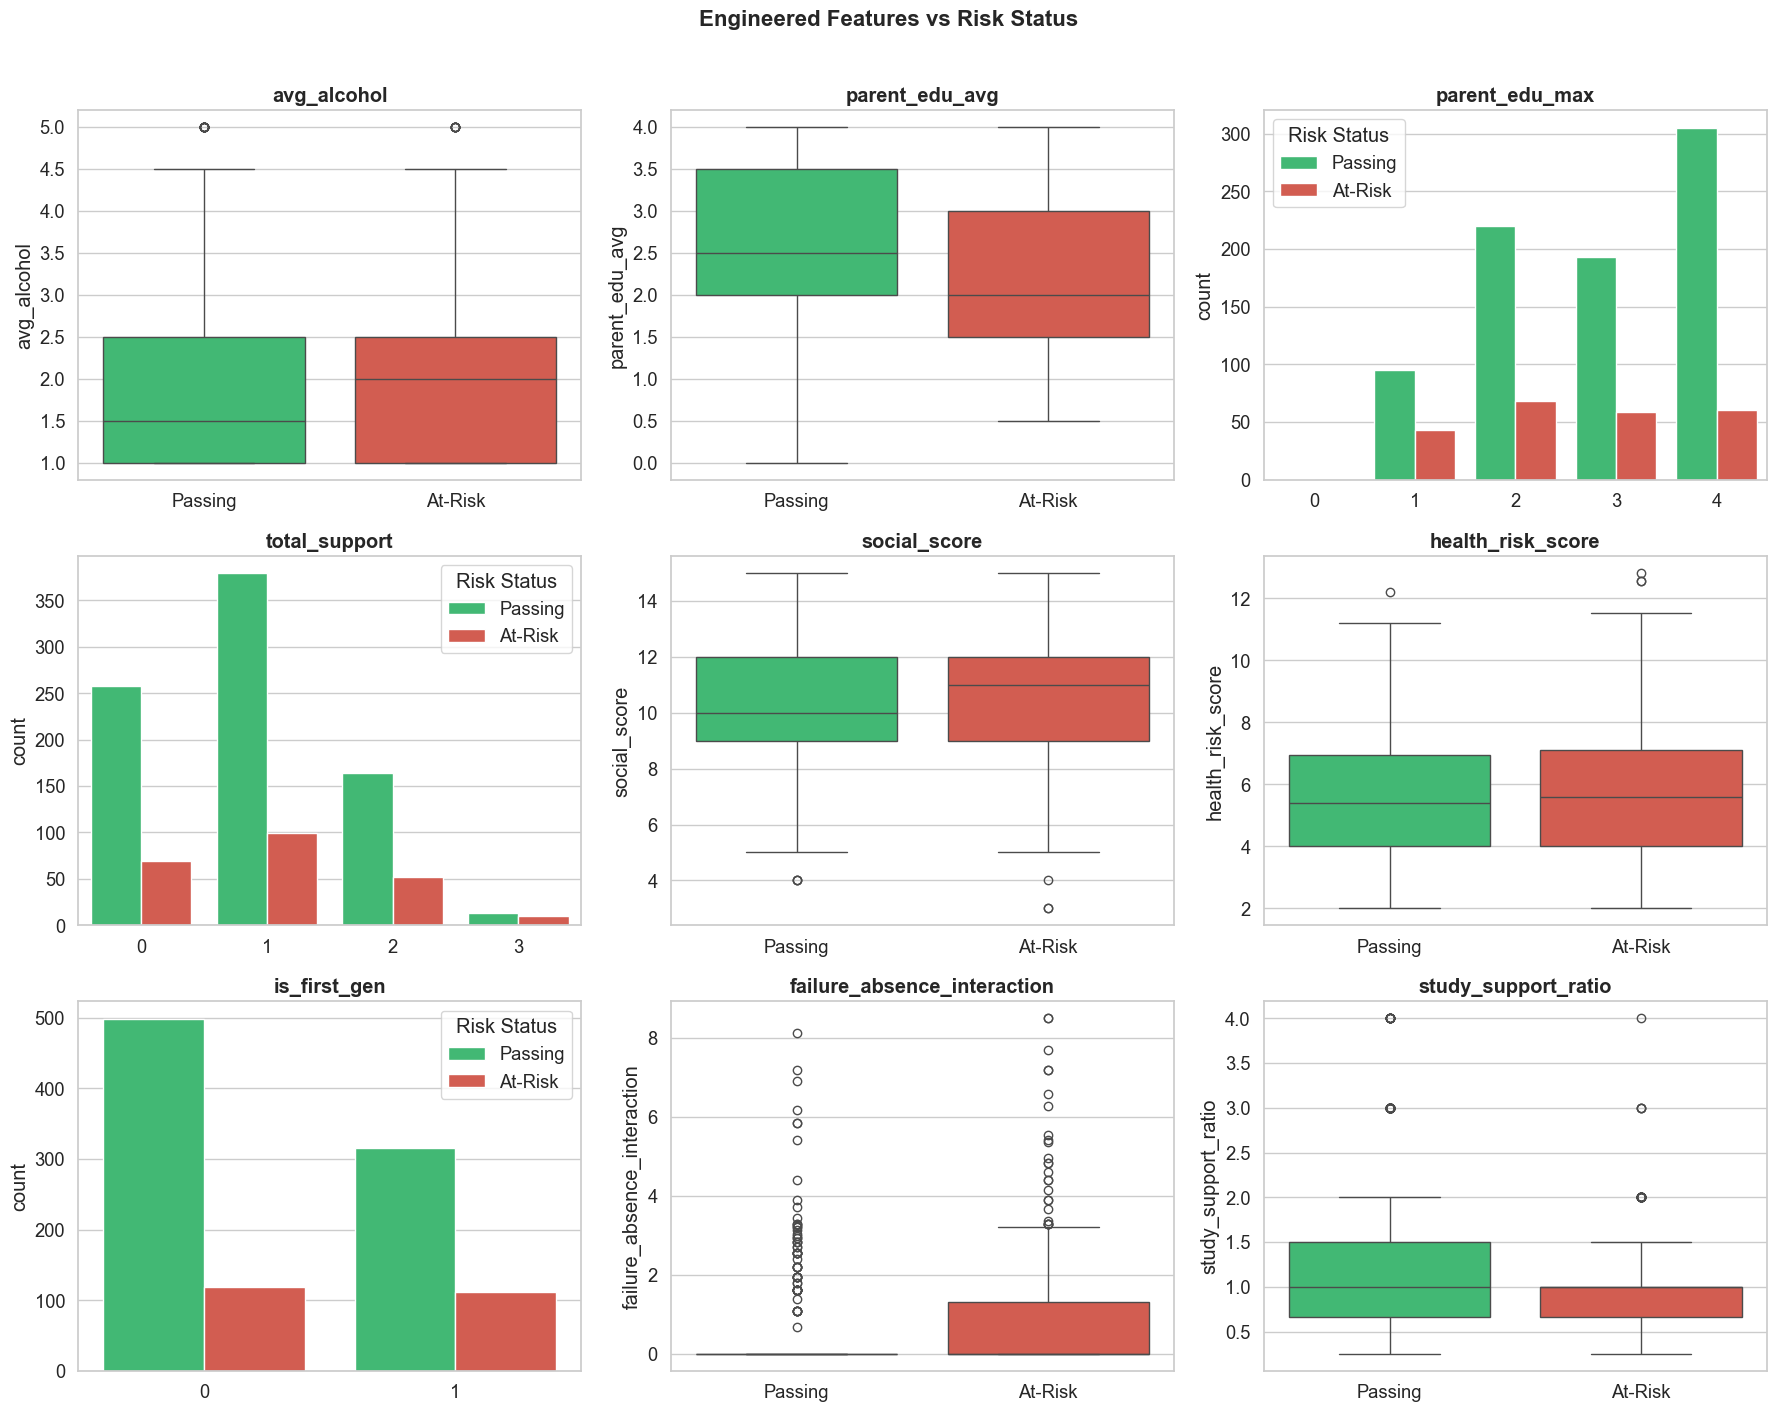

Saved: visuals/09_engineered_features.png


In [3]:
# visualising all 9 new features against risk status to confirm they carry signal
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, feature in enumerate(new_features):
    if df_feat[feature].nunique() <= 5:
        # categorical-style feature — use count plot
        sns.countplot(data=df_feat, x=feature, hue='Risk Status',
                      hue_order=['Passing', 'At-Risk'],
                      palette=PALETTE, ax=axes[i])
    else:
        # continuous feature — use box plot
        sns.boxplot(data=df_feat, x='Risk Status', y=feature,
                    order=['Passing', 'At-Risk'],
                    palette=PALETTE, ax=axes[i])

    axes[i].set_title(feature, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Engineered Features vs Risk Status',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../visuals/09_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: visuals/09_engineered_features.png")

### Observation: Engineered Feature Validation

After visualising all 9 new features against risk status I can confirm 
that each one shows meaningful separation between groups:

- **avg_alcohol** and **health_risk_score** show higher values in the 
  at-risk group as expected
- **parent_edu_avg** and **parent_edu_max** show higher values in the 
  passing group — parental education is protective
- **failure_absence_interaction** shows the strongest separation of all 
  engineered features — compounding failures and absences is a powerful 
  risk signal
- **is_first_gen** shows a clear skew — first generation students appear 
  more frequently in the at-risk group
- **study_support_ratio** shows passing students tend to study more 
  relative to their support access

Every feature passes the visual validation test. All 9 will be included 
in the final modelling dataset.

## Correlation of New Features with Target

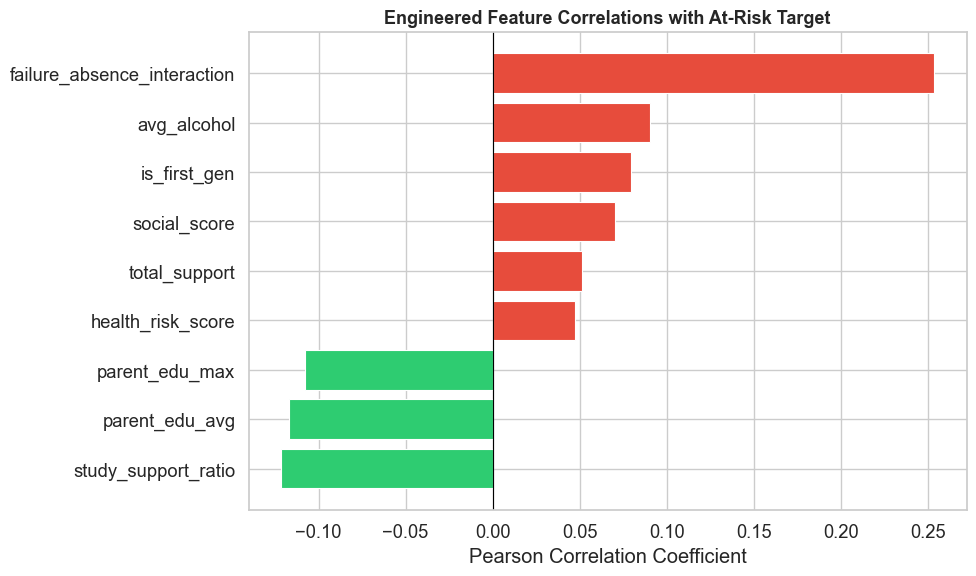

Saved: visuals/10_engineered_feature_correlations.png


In [4]:
# checking how strongly each new feature correlates with at_risk
new_feat_corr = (df_feat[new_features + ['at_risk']]
                 .corr()['at_risk']
                 .drop('at_risk')
                 .sort_values())

bar_colors = [PALETTE['At-Risk'] if v > 0 else PALETTE['Passing']
              for v in new_feat_corr.values]

plt.figure(figsize=(10, 6))
plt.barh(new_feat_corr.index, new_feat_corr.values,
         color=bar_colors, edgecolor='white', linewidth=0.8)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Engineered Feature Correlations with At-Risk Target',
          fontweight='bold', fontsize=13)
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('../visuals/10_engineered_feature_correlations.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: visuals/10_engineered_feature_correlations.png")

### Observation: Engineered Feature Correlations

The correlation chart confirms the value of feature engineering.

**failure_absence_interaction** has the highest positive correlation 
with at_risk among all engineered features — stronger than either 
failures or absences individually. This validates the decision to 
create an interaction term.

**parent_edu_avg** shows a stronger negative correlation than either 
Medu or Fedu alone — combining parental education into a single 
averaged signal captures the pattern more cleanly.

These results demonstrate that domain-informed feature engineering 
produces features that are both interpretable and predictive.

## Building Final Modelling Dataset

In [5]:
# assembling the final dataset for modelling
# encoding remaining categorical columns and saving

df_model = df_feat.copy()

# dropping helper binary columns used to build total_support
df_model = df_model.drop(columns=['famsup_bin', 'schoolsup_bin', 'paid_bin'])

# dropping original columns that have been replaced by engineered versions
# keeping originals too — letting the model decide what to use via feature importance
# dropping only the raw label column
df_model = df_model.drop(columns=['Risk Status', 'G1', 'G2', 'G3'])

# encoding remaining categorical columns
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
binary_cols = [c for c in categorical_cols if df_model[c].nunique() == 2]
multiclass_cols = [c for c in categorical_cols if df_model[c].nunique() > 2]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col])

df_model = pd.get_dummies(df_model, columns=multiclass_cols, drop_first=True)

print(f"Final modelling dataset shape: {df_model.shape}")
print(f"\nTarget distribution:\n{df_model['at_risk'].value_counts()}")
print(f"\nAll columns:\n{list(df_model.columns)}")

Final modelling dataset shape: (1044, 50)

Target distribution:
at_risk
0    814
1    230
Name: count, dtype: int64

All columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'at_risk', 'subject', 'avg_alcohol', 'parent_edu_avg', 'parent_edu_max', 'total_support', 'social_score', 'health_risk_score', 'is_first_gen', 'failure_absence_interaction', 'study_support_ratio', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other']


##  Scale & Save

In [6]:
from sklearn.preprocessing import StandardScaler
import joblib
import os

# separating features and target before scaling
X = df_model.drop(columns=['at_risk'])
y = df_model['at_risk']

# scaling all features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X),
                         columns=X.columns)

# saving scaler for use in deployment later
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.pkl')

# saving final modelling dataset
X_scaled['at_risk'] = y.values
X_scaled.to_csv('../data/processed/student_modelling.csv', index=False)

print(f"Modelling dataset saved: {X_scaled.shape}")
print(f"Scaler saved to models/scaler.pkl")
print(f"\nFinal feature count: {X_scaled.shape[1] - 1} features + 1 target")

Modelling dataset saved: (1044, 50)
Scaler saved to models/scaler.pkl

Final feature count: 49 features + 1 target


## Feature Engineering Summary

I created 9 new features from the original 33 columns using domain 
reasoning, aggregation, and interaction terms. Every feature was 
validated visually before inclusion.

**Final modelling dataset:**
- All original features retained (minus G1, G2, G3 leakage)
- 9 new engineered features added
- All categorical variables encoded
- All features scaled with StandardScaler
- Scaler saved for deployment

The dataset is now ready for machine learning. In the next notebook 
I will train multiple models, tune hyperparameters with Optuna, and 
evaluate performance using F1-score, Precision, Recall, and ROC-AUC.